In [1]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import (
    chi2_contingency,
    randint,
    uniform,
    loguniform
)

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.feature_selection import (
    mutual_info_classif,
    SelectFromModel
)
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.manifold import TSNE
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    recall_score,
    precision_score,
    roc_curve,
    roc_auc_score
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    cross_val_predict,
    train_test_split,
    RandomizedSearchCV
)
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    RobustScaler,
    FunctionTransformer
)

# Models of interest
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Imbalanced-learn
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.ensemble import BalancedBaggingClassifier

# Skorch / PyTorch
import torch
import torch.nn as nn
from torch.optim import Adam
from skorch import NeuralNetClassifier
from skorch.callbacks import EarlyStopping

# Custom module
from JCC_module import *

import joblib



warnings.filterwarnings("ignore")


In [2]:
date_cols =date_cols_list()

In [3]:
date_cols.load_from_txt()

In [4]:
date_cols = date_cols.return_object()

In [5]:
type(date_cols)

list

In [6]:
date_cols

['issue_d',
 'last_pymnt_d',
 'last_credit_pull_d',
 'next_pymnt_d',
 'earliest_cr_line']

In [7]:
cols_to_drop = cols_to_drop()

In [8]:
cols_to_drop.load_from_txt()

In [9]:
cols_to_drop.show_list()

['url', 'emp_title', 'title', 'pymnt_plan', 'zip_code', 'application_type', 'initial_list_status', 'verification_status_joint', 'Unnamed: 0', 'policy_code', 'id']


In [10]:
cols_to_drop.add_cols(["recoveries","collection_recovery_fee"])

In [11]:
leakage_cols = [
    "out_prncp_inv",
    "total_rec_late_fee",
    "last_pymnt_amnt",
    "debt_settlement_flag",
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_int"
]

In [12]:
cols_to_drop.add_cols(leakage_cols)

In [13]:
cols_to_drop.add_col("hardship_flag")

In [14]:
cols_to_drop.show_list()

['url', 'emp_title', 'title', 'pymnt_plan', 'zip_code', 'application_type', 'initial_list_status', 'verification_status_joint', 'Unnamed: 0', 'policy_code', 'id', 'recoveries', 'collection_recovery_fee', 'out_prncp_inv', 'total_rec_late_fee', 'last_pymnt_amnt', 'debt_settlement_flag', 'total_pymnt', 'total_pymnt_inv', 'total_rec_int', 'hardship_flag']


## Cross Validation

In [15]:
df = pd.read_csv("Post_EDA_data2.csv")

In [16]:
df.shape

(2029952, 142)

In [17]:
df.head()

,Unnamed: 0,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag,y
0,0,120122535,12000.0,12000.0,12000.0,36 months,7.97%,375.88,A,A5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,1
1,1,119374887,32000.0,32000.0,32000.0,36 months,11.99%,1062.71,B,B5,...,Jun-2020,Apr-2020,2.0,0.0,ACTIVE,123.08000,6189.66,1062.71,N,1
2,2,119321612,40000.0,40000.0,40000.0,60 months,15.05%,952.65,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,1
3,3,120122034,16000.0,16000.0,16000.0,36 months,7.97%,501.17,A,A5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,1
4,4,118659541,33000.0,33000.0,33000.0,36 months,7.21%,1022.12,A,A3,...,Apr-2020,Feb-2020,3.0,21.0,DELINQUENT,177.96231,10197.78,59.68,N,0


In [18]:
X = df.drop("y",axis=1)
y= df["y"]

In [19]:
#subsample a subset of the data
X_sub = X.sample(n=200000, random_state=42)
y_sub = y.loc[X_sub.index]

In [20]:
print(len(X_sub))
print(len(y_sub))

200000
200000


In [21]:
X_train,X_val,X_test,y_train,y_val,y_test = train_test_val_split(X_sub,70,15,15,stratify_arr=y_sub,random_state=42)

In [22]:
X_train.shape

(140000, 141)

In [23]:
X_val.shape

(30000, 141)

In [24]:
X_test.shape

(30000, 141)

In [25]:
numerical_columns, categorical_cols = obtain_col_types(df,include_date_columns=False)

In [26]:
numerical_columns.remove("y")

In [27]:
#Sample the numerical columns only from the training data
X_sample = X_train.sample(n=5000, random_state=42)
y_sample = y_train.loc[X_sample.index]

In [28]:
#Only numerical columns
X_num_sample = X_sample[numerical_columns]
X_num_sample.head()

,Unnamed: 0,id,loan_amnt,funded_amnt,funded_amnt_inv,installment,annual_inc,dti,delinq_2yrs,fico_range_low,...,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount
1308177,335957,44139662,5000.0,5000.0,5000.0,179.69,20000.0,35.29,0.0,735.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
690673,82494,142888035,37600.0,37600.0,37600.0,1164.60,325000.0,12.62,1.0,770.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
568761,88776,137631748,9000.0,9000.0,9000.0,290.75,33000.0,27.71,0.0,675.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1425531,32216,73968342,28000.0,28000.0,27900.0,658.21,121400.0,5.07,0.0,755.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1588854,61652,77350573,28000.0,28000.0,28000.0,780.52,110000.0,14.87,5.0,665.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
cols_to_drop = cols_to_drop.return_object()

In [30]:
cols_to_drop

['url',
 'emp_title',
 'title',
 'pymnt_plan',
 'zip_code',
 'application_type',
 'initial_list_status',
 'verification_status_joint',
 'Unnamed: 0',
 'policy_code',
 'id',
 'recoveries',
 'collection_recovery_fee',
 'out_prncp_inv',
 'total_rec_late_fee',
 'last_pymnt_amnt',
 'debt_settlement_flag',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_int',
 'hardship_flag']

In [31]:
cols_to_drop.remove("Unnamed: 0")

In [32]:
cols_to_drop

['url',
 'emp_title',
 'title',
 'pymnt_plan',
 'zip_code',
 'application_type',
 'initial_list_status',
 'verification_status_joint',
 'policy_code',
 'id',
 'recoveries',
 'collection_recovery_fee',
 'out_prncp_inv',
 'total_rec_late_fee',
 'last_pymnt_amnt',
 'debt_settlement_flag',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_int',
 'hardship_flag']

In [33]:
fe = Feature_engineering_step(date_cols=date_cols,cols_to_drop=cols_to_drop)

X_train_fe = fe.fit_transform(X_train)
X_val_fe = fe.transform(X_val)
X_test_fe = fe.transform(X_test)

In [34]:
X_train_fe.shape

(140000, 121)

In [35]:
#X_train_fe.to_csv("X_train_fe.csv", index=False)
#X_val_fe.to_csv("X_val_fe.csv", index=False)
#X_test_fe.to_csv("X_test_fe.csv", index= False)

In [36]:
#y_train.to_csv("y_train.csv", index=False)
#y_val.to_csv("y_val.csv", index=False)
#y_test.to_csv("y_test.csv", index= False)

## PCA & t-nse

In [37]:
#Consruct the numerical pipeline and fit transform
#Try standard scaler and Robust
num_only_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", RobustScaler())
])

X_num_processed = num_only_pipe.fit_transform(X_num_sample)

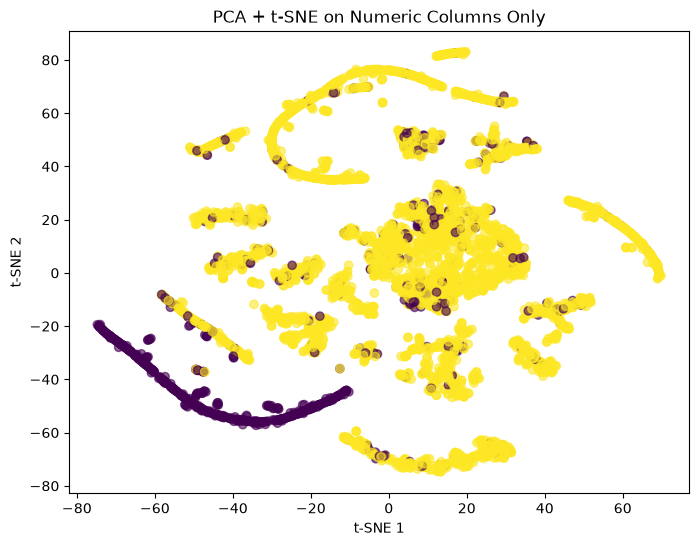

In [38]:
X_tsne = PCA_tnse(numerical_pipeline=num_only_pipe,n_comp_tsne=2,n_comp_pca=30,perplexity=30,random_state=42)
X_tsne = X_tsne.plot(X=X_num_sample,y=y_sample)

## ---------------------------

## Pipeline creation & post-transformation evaluation & Univariate variable selection

## Variable Selection via tree-based model

## Model selection

Here is the list of models, that are a candidate pool of models
* (FFN) Feed forward Nueral Network
* Logistic regression
* Xg Boost
* random forest

Research Goal: Can we predict whether a LendingClub loan is in good standing based on the borrower’s current financial and credit profile?

## Preprocessing & feature selection pipeline

## -----------------------------------------------------------

# Baseline with the added missing_val_droppers

In [39]:

categorical_pipeline = Pipeline([
    ("drop_missing_cols", Missing_val_dropper(threshold=50.0)),
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing", add_indicator=True)),
    ("cat_selector", CategoricalFeatureSelector(threshold=0.80)),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

numerical_pipeline = Pipeline([
    ("drop_missing_cols", Missing_val_dropper(threshold=50.0)),
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("outlier", OutlierFlaggerv2()),
    ("scaler", RobustScaler())
])

In [40]:

#I barely added the missing indicator when it should have been in the beggining 5/14. Will use it for the final model evaluation
categorical_pipeline = build_categorical_pipeline()
numerical_pipeline = build_numerical_pipeline()

In [41]:
numerical_columns_train_fe, categorical_columns_train_fe = obtain_col_types(X_train_fe,include_date_columns=False)

In [42]:
preprocessing = ColumnTransformer([
    ("cat", categorical_pipeline, categorical_columns_train_fe),
    ("num", numerical_pipeline, numerical_columns_train_fe)
], remainder="passthrough")

In [43]:
preprocessing = build_preprocessor(numerical_cols=numerical_columns_train_fe, categorical_cols=categorical_columns_train_fe)

In [44]:
#Shows how to swap steps from the build pipeline in case you want to play with the settings
#numerical_pipeline.steps[3] = ("outlier", StandardScaler())
#numerical_pipeline

In [45]:
#How to swap before fitting the pipeline
#num_pipe = preprocessing.transformers[1][1]
#num_pipe.steps[3] = ("scaler", StandardScaler())


In [46]:
preprocessing.set_output(transform="pandas")

,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,threshold,50.0
,missing_values,nan
,strategy,'constant'


In [47]:
baseline_pipeline = Pipeline([
    ("process", preprocessing),
    ("corr_selector", CorrelationFeatureSelector(threshold=0.80)),
    ("tree_selector", SelectFromModel(
        RandomForestClassifier(n_estimators=300, random_state=42),
        threshold="mean"
    )),
    ("model", LogisticRegression(max_iter=1000))
])

In [48]:
baseline_pipeline.fit(X_train_fe, y_train)

,steps,"[('process', ...), ('corr_selector', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


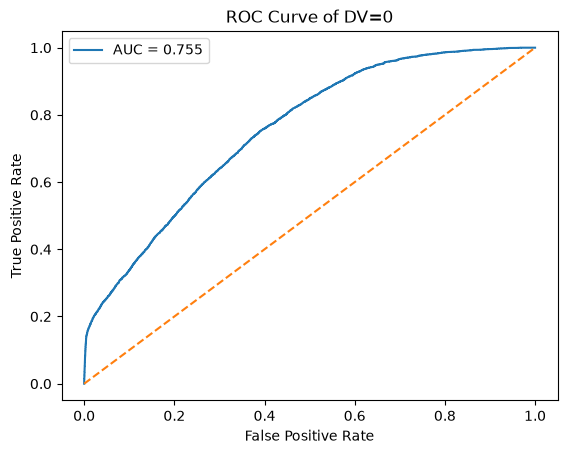

              precision    recall  f1-score   support

           0       0.81      0.15      0.25      4822
           1       0.86      0.99      0.92     25178

    accuracy                           0.86     30000
   macro avg       0.83      0.57      0.59     30000
weighted avg       0.85      0.86      0.81     30000

current model AUC:0.754667
current model name:base


In [49]:
model_summary(baseline_pipeline, X_val_fe, y_val, "base")

## -----------------------------------------------------------

## Pipeline name extraction

## Slightly more complex model selection

In [50]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [51]:
#to make a score that is f1, score but to detect it on the minority cl asss 0
f1_class_0 = make_scorer(f1_score, pos_label=0)

In [52]:
pipe = Pipeline([
    ("preprocess", preprocessing),
    ("corr_selector", CorrelationFeatureSelector(threshold=0.80)),
    ("tree_selector", SelectFromModel(
        RandomForestClassifier(n_estimators=300, random_state=42),
        threshold="mean"
    )),
    ("sampler", "passthrough"),
    ("model", LogisticRegression(max_iter=1000))
])

In [53]:
n_class_0 = (y_train == 0).sum()
n_class_1 = (y_train == 1).sum()

n_class_0, n_class_1
scale_pos_weight = n_class_0 / n_class_1

In [54]:
param_XGB_sampler = [
    #Note to self 5/11: try with smote
    #Each dictionary value is for each model set up, like for example each differnt versions of Logistic regression are based on the different model penalties, and not all can use other model penalties
    

    # XGBoost
    {
        "preprocess__num__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
        "preprocess__cat__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
        "sampler": [
    
    # Undersampling
    # RandomUnderSampler(sampling_strategy=0.30, random_state=42),
    # RandomUnderSampler(sampling_strategy=0.40, random_state=42),
    # RandomUnderSampler(sampling_strategy=0.50, random_state=42),
    # RandomUnderSampler(sampling_strategy=0.70, random_state=42),

    # Oversampling
    # RandomOverSampler(sampling_strategy=0.25, random_state=42),
    # RandomOverSampler(sampling_strategy=0.35, random_state=42),
    # RandomOverSampler(sampling_strategy=0.50, random_state=42),

    
    # SMOTE
    SMOTE(sampling_strategy=0.25, k_neighbors=3, random_state=42),
    SMOTE(sampling_strategy=0.35, k_neighbors=3, random_state=42),
    SMOTE(sampling_strategy=0.50, k_neighbors=3, random_state=42),

    SMOTE(sampling_strategy=0.25, k_neighbors=5, random_state=42),
    SMOTE(sampling_strategy=0.35, k_neighbors=5, random_state=42),
    SMOTE(sampling_strategy=0.50, k_neighbors=5, random_state=42),

    SMOTE(sampling_strategy=0.70, k_neighbors=5, random_state=42)
],
        'model': [XGBClassifier(
            random_state=42,
            eval_metric='logloss'
        )],
        'model__n_estimators': [100, 300, 500,800],
        'model__learning_rate': [0.01, 0.05, 0.1],
        "model__booster": ["gbtree"], #removed "dart"
        'model__max_depth': [3, 4, 5],
        'model__subsample': [0.6, 0.8, 1.0],
        'model__colsample_bytree': [0.6, 0.8, 1.0],
        # Regularization
        'model__reg_alpha': [0, 0.01, 0.1, 1],
        'model__reg_lambda': [1, 5, 10]
    }
]

In [55]:
XGB_sampler_model_smoted = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_XGB_sampler,
    n_iter=1,
    scoring=f1_class_0,
    cv=2,
    n_jobs=-1,
    random_state=42,
    verbose=0
)

XGB_sampler_model_smoted.fit(X_train_fe, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"[{'model': [XGBClassifier...ree=None, ...)], 'model__booster': ['gbtree'], 'model__colsample_bytree': [0.6, 0.8, ...], 'model__learning_rate': [0.01, 0.05, ...], ...}]"
,n_iter,1
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,-1
,refit,True
,cv,2
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [56]:
Model_evaluator(XGB_sampler_model_smoted,X_val=X_val_fe,y_val=y_val,pos_label=0).full_summary()

F1 optimal threshold for class 0: 0.21212121212121213
Classification report with threshold
              precision    recall  f1-score   support

           0       0.30      0.59      0.40      4822
           1       0.90      0.74      0.81     25178

    accuracy                           0.71     30000
   macro avg       0.60      0.66      0.61     30000
weighted avg       0.81      0.71      0.75     30000

Youden threshold for class 0: 0.17603695392608643
Classification report with Youden threshold
              precision    recall  f1-score   support

           0       0.27      0.75      0.39      4822
           1       0.93      0.60      0.73     25178

    accuracy                           0.63     30000
   macro avg       0.60      0.68      0.56     30000
weighted avg       0.82      0.63      0.68     30000


optimal f1 : 0.2121
              precision    recall  f1-score   support

           0       0.30      0.59      0.40      4822
           1       0.90      0.

In [57]:
best_XGB_sampler_model = XGB_sampler_model_smoted.best_estimator_

In [58]:
#joblib.dump(best_XGB_sampler_model, "best_XGB_sampler_model_smoted.pkl")

In [61]:
#loaded_model = joblib.load("best_XGB_sampler_model_smoted.pkl")

In [62]:
#print(model_summary(loaded_model, X_val_fe, y_val, "Best Random Search Model"))

In [63]:
XGB_param_no_sampler = [

    # XGBoost
    {
    "preprocess__num__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
    "preprocess__cat__drop_missing_cols__threshold": [50, 60, 70, 80, 90],

    "sampler": ["passthrough"],

    "model": [
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
    ],

    "model__n_estimators": [100, 300, 500, 800],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 4, 5],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__booster": ["gbtree"],#"dart"

    "model__scale_pos_weight": [scale_pos_weight, 5, 10, 20],

    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [1, 5, 10]
}
]

In [64]:
XGB_no_sampler_model = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=XGB_param_no_sampler,
    n_iter=2,
    scoring=f1_class_0,
    cv=2,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

XGB_no_sampler_model.fit(X_train_fe, y_train)

Fitting 2 folds for each of 2 candidates, totalling 4 fits


,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"[{'model': [XGBClassifier...ree=None, ...)], 'model__booster': ['gbtree'], 'model__colsample_bytree': [0.6, 0.8, ...], 'model__learning_rate': [0.01, 0.05, ...], ...}]"
,n_iter,2
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,-1
,refit,True
,cv,2
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [65]:
#joblib.dump(XGB_no_sampler_model, "XGB_no_sampler_model.pkl")

In [66]:
Model_evaluator(XGB_no_sampler_model,X_val=X_val_fe,y_val=y_val,pos_label=0).full_summary()

F1 optimal threshold for class 0: 0.020202020202020204
Classification report with threshold
              precision    recall  f1-score   support

           0       0.28      0.68      0.40      4822
           1       0.92      0.66      0.77     25178

    accuracy                           0.67     30000
   macro avg       0.60      0.67      0.58     30000
weighted avg       0.81      0.67      0.71     30000

Youden threshold for class 0: 0.01719033718109131
Classification report with Youden threshold
              precision    recall  f1-score   support

           0       0.26      0.79      0.39      4822
           1       0.93      0.57      0.70     25178

    accuracy                           0.60     30000
   macro avg       0.60      0.68      0.55     30000
weighted avg       0.83      0.60      0.65     30000


optimal f1 : 0.0202
              precision    recall  f1-score   support

           0       0.28      0.68      0.40      4822
           1       0.92      0

In [67]:
XGB_param_mixed = [

    # XGBoost
    {
    "preprocess__num__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
    "preprocess__cat__drop_missing_cols__threshold": [50, 60, 70, 80, 90],

    "sampler": [
    # Undersampling
    RandomUnderSampler(sampling_strategy=0.30, random_state=42),
    RandomUnderSampler(sampling_strategy=0.40, random_state=42),
    RandomUnderSampler(sampling_strategy=0.50, random_state=42),
    RandomUnderSampler(sampling_strategy=0.70, random_state=42),

    # Oversampling
    RandomOverSampler(sampling_strategy=0.25, random_state=42),
    RandomOverSampler(sampling_strategy=0.35, random_state=42),
    RandomOverSampler(sampling_strategy=0.50, random_state=42),

    # SMOTE
    SMOTE(sampling_strategy=0.25, k_neighbors=3, random_state=42),
    SMOTE(sampling_strategy=0.35, k_neighbors=3, random_state=42),
    SMOTE(sampling_strategy=0.50, k_neighbors=3, random_state=42),

    SMOTE(sampling_strategy=0.25, k_neighbors=5, random_state=42),
    SMOTE(sampling_strategy=0.35, k_neighbors=5, random_state=42),
    SMOTE(sampling_strategy=0.50, k_neighbors=5, random_state=42),

    SMOTE(sampling_strategy=0.70, k_neighbors=5, random_state=42),
],

    "model": [
        XGBClassifier(
            random_state=42,
            eval_metric="logloss",
            objective="binary:logistic"
        )
    ],

    "model__n_estimators": [100, 300, 500, 800],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 4, 5],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__booster": ["gbtree"],#"dart"

    "model__scale_pos_weight": [scale_pos_weight, 5, 10, 20],

    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [1, 5, 10]
}
]

In [68]:
XGB_mixed_model = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=XGB_param_mixed,
    n_iter=1,
    scoring=f1_class_0,
    cv=2,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

XGB_mixed_model.fit(X_train_fe, y_train)

Fitting 2 folds for each of 1 candidates, totalling 2 fits


,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"[{'model': [XGBClassifier...ree=None, ...)], 'model__booster': ['gbtree'], 'model__colsample_bytree': [0.6, 0.8, ...], 'model__learning_rate': [0.01, 0.05, ...], ...}]"
,n_iter,1
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,-1
,refit,True
,cv,2
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [69]:
#joblib.dump(XGB_mixed_model, "XGB_mixed_model.pkl")

In [70]:
Model_evaluator(XGB_mixed_model,X_val=X_val_fe,y_val=y_val,pos_label=0).full_summary()

F1 optimal threshold for class 0: 0.8181818181818182
Classification report with threshold
              precision    recall  f1-score   support

           0       0.30      0.58      0.40      4822
           1       0.90      0.74      0.82     25178

    accuracy                           0.72     30000
   macro avg       0.60      0.66      0.61     30000
weighted avg       0.81      0.72      0.75     30000

Youden threshold for class 0: 0.7759426236152649
Classification report with Youden threshold
              precision    recall  f1-score   support

           0       0.27      0.75      0.39      4822
           1       0.93      0.60      0.73     25178

    accuracy                           0.63     30000
   macro avg       0.60      0.68      0.56     30000
weighted avg       0.82      0.63      0.68     30000


optimal f1 : 0.8182
              precision    recall  f1-score   support

           0       0.30      0.58      0.40      4822
           1       0.90      0.74

In [71]:
param_dist_random_forest = [
    {
        "preprocess__num__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
        "preprocess__cat__drop_missing_cols__threshold": [50, 60, 70, 80, 90],

        "sampler": [
            RandomUnderSampler(sampling_strategy=0.30, random_state=42),
            RandomUnderSampler(sampling_strategy=0.50, random_state=42),
            RandomUnderSampler(sampling_strategy=0.70, random_state=42),

            RandomOverSampler(sampling_strategy=0.35, random_state=42),
            RandomOverSampler(sampling_strategy=0.50, random_state=42),

            SMOTE(sampling_strategy=0.35, k_neighbors=5, random_state=42),
            SMOTE(sampling_strategy=0.50, k_neighbors=5, random_state=42),
            SMOTE(sampling_strategy=0.70, k_neighbors=5, random_state=42),
        ],

        "model": [RandomForestClassifier(random_state=42, n_jobs=-1)],

        "model__n_estimators": [300, 500, 800,1000],
        "model__max_depth": [None, 10, 20, 30],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 5, 10],
        "model__max_features": ["sqrt", "log2"],
        "model__criterion": ["gini", "entropy"],

        "model__class_weight": ["balanced", {0: 2, 1: 1},
    {0: 3, 1: 1},
    {0: 5, 1: 1}],

        "model__bootstrap": [True, False],
    }
]

In [72]:
rf_model = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist_random_forest,
    n_iter=1,
    scoring=f1_class_0,
    cv=2,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

rf_model.fit(X_train_fe, y_train)

Fitting 2 folds for each of 1 candidates, totalling 2 fits


,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"[{'model': [RandomForestC...ndom_state=42)], 'model__bootstrap': [True, False], 'model__class_weight': ['balanced', {0: 2, 1: 1}, ...], 'model__criterion': ['gini', 'entropy'], ...}]"
,n_iter,1
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,-1
,refit,True
,cv,2
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [73]:
#joblib.dump(rf_model, "rf_model.pkl")

In [74]:
Model_evaluator(rf_model,X_val=X_val_fe,y_val=y_val,pos_label=0).full_summary()

F1 optimal threshold for class 0: 0.48484848484848486
Classification report with threshold
              precision    recall  f1-score   support

           0       0.29      0.58      0.39      4822
           1       0.90      0.73      0.81     25178

    accuracy                           0.70     30000
   macro avg       0.59      0.65      0.60     30000
weighted avg       0.80      0.70      0.74     30000

Youden threshold for class 0: 0.41188031509198547
Classification report with Youden threshold
              precision    recall  f1-score   support

           0       0.25      0.78      0.38      4822
           1       0.93      0.55      0.69     25178

    accuracy                           0.58     30000
   macro avg       0.59      0.66      0.53     30000
weighted avg       0.82      0.58      0.64     30000


optimal f1 : 0.4848
              precision    recall  f1-score   support

           0       0.29      0.58      0.39      4822
           1       0.90      0.

In [75]:
bbc = BalancedBaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    sampling_strategy="auto",
    replacement=False,
    random_state=42,
    n_jobs=-1
)

In [76]:

param_bagging = [
    {
        "model": [
            BalancedBaggingClassifier(
                estimator=DecisionTreeClassifier(random_state=42),
                random_state=42,
                n_jobs=1
            )
        ],

        # Stronger imbalance handling
        "model__sampling_strategy": ["auto", 0.3, 0.5, 0.7, 1.0],
        "model__replacement": [True, False],

        # More trees = more stable
        "model__n_estimators": [100, 300, 500,800],

        # Control tree overfitting
        "model__estimator__max_depth": [3, 5, 10, 20, None],
        "model__estimator__min_samples_leaf": [1, 2, 5, 10, 20],
        "model__estimator__min_samples_split": [2, 5, 10, 20],

        # Extra imbalance pressure inside each tree
        "model__estimator__class_weight": ["balanced"],

        # Randomness / diversity
        "model__max_samples": [0.5, 0.75, 1.0],
        "model__max_features": [0.5, 0.75, 1.0]
    }
]

In [77]:
bagging_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_bagging,
    n_iter=1,
    scoring=f1_class_0,
    cv=2,
    n_jobs=1,
    random_state=42,
    verbose=0
)

bagging_search.fit(X_train_fe, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"[{'model': [BalancedBaggi...ndom_state=42)], 'model__estimator__class_weight': ['balanced'], 'model__estimator__max_depth': [3, 5, ...], 'model__estimator__min_samples_leaf': [1, 2, ...], ...}]"
,n_iter,1
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,1
,refit,True
,cv,2
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [78]:
#joblib.dump(bagging_search, "bagging_search_model.pkl")

In [79]:
Model_evaluator(bagging_search,X_val=X_val_fe,y_val=y_val,pos_label=0).full_summary()

F1 optimal threshold for class 0: 0.5555555555555556
Classification report with threshold
              precision    recall  f1-score   support

           0       0.31      0.58      0.40      4822
           1       0.90      0.75      0.82     25178

    accuracy                           0.72     30000
   macro avg       0.60      0.66      0.61     30000
weighted avg       0.81      0.72      0.75     30000

Youden threshold for class 0: 0.5014170028414923
Classification report with Youden threshold
              precision    recall  f1-score   support

           0       0.26      0.77      0.39      4822
           1       0.93      0.58      0.71     25178

    accuracy                           0.61     30000
   macro avg       0.59      0.67      0.55     30000
weighted avg       0.82      0.61      0.66     30000


optimal f1 : 0.5556
              precision    recall  f1-score   support

           0       0.31      0.58      0.40      4822
           1       0.90      0.75

## Pipeline name extraction

In [80]:
lr_l2_sampler_param = [
    {
        "preprocess__num__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
        "preprocess__cat__drop_missing_cols__threshold": [50, 60, 70, 80, 90],

        "sampler": [
            # No sampler baseline inside sampler search
            "passthrough",

            # Undersampling majority class
            RandomUnderSampler(sampling_strategy=0.30, random_state=42),
            RandomUnderSampler(sampling_strategy=0.50, random_state=42),
            RandomUnderSampler(sampling_strategy=0.70, random_state=42),

            # Oversampling minority class 0
            RandomOverSampler(sampling_strategy=0.30, random_state=42),
            RandomOverSampler(sampling_strategy=0.50, random_state=42),
            RandomOverSampler(sampling_strategy=0.70, random_state=42),

            # SMOTE versions
            SMOTE(sampling_strategy=0.30, k_neighbors=3, random_state=42),
            SMOTE(sampling_strategy=0.50, k_neighbors=3, random_state=42),
            SMOTE(sampling_strategy=0.70, k_neighbors=3, random_state=42),

            SMOTE(sampling_strategy=0.30, k_neighbors=5, random_state=42),
            SMOTE(sampling_strategy=0.50, k_neighbors=5, random_state=42),
            SMOTE(sampling_strategy=0.70, k_neighbors=5, random_state=42),
        ],

        "model": [
            LogisticRegression(
                max_iter=5000,
                fit_intercept=True,
                random_state=42
            )
        ],

        "model__penalty": ["l2"],
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__solver": ["lbfgs", "saga"],
        "model__class_weight": [None],
        "model__tol": [1e-4, 1e-3]
    }
]

In [81]:
lr_l2_sampler_model = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=lr_l2_sampler_param,
    n_iter=1,
    scoring=f1_class_0,
    cv=2,
    n_jobs=-1,
    random_state=42,
    verbose=0
)

lr_l2_sampler_model.fit(X_train_fe, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"[{'model': [LogisticRegre...ndom_state=42)], 'model__C': [0.001, 0.01, ...], 'model__class_weight': [None], 'model__penalty': ['l2'], ...}]"
,n_iter,1
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,-1
,refit,True
,cv,2
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [82]:
#joblib.dump(lr_l2_sampler_model, "lr_l2_sampler_model.pkl")

In [83]:
Model_evaluator(lr_l2_sampler_model,X_val=X_val_fe,y_val=y_val,pos_label=0).full_summary()

F1 optimal threshold for class 0: 0.4646464646464647
Classification report with threshold
              precision    recall  f1-score   support

           0       0.31      0.58      0.40      4822
           1       0.90      0.75      0.82     25178

    accuracy                           0.72     30000
   macro avg       0.61      0.67      0.61     30000
weighted avg       0.81      0.72      0.75     30000

Youden threshold for class 0: 0.39946315422730194
Classification report with Youden threshold
              precision    recall  f1-score   support

           0       0.26      0.78      0.39      4822
           1       0.93      0.58      0.72     25178

    accuracy                           0.61     30000
   macro avg       0.60      0.68      0.55     30000
weighted avg       0.82      0.61      0.66     30000


optimal f1 : 0.4646
              precision    recall  f1-score   support

           0       0.31      0.58      0.40      4822
           1       0.90      0.7

In [84]:
lr_l1_sampler_param = [
    {
        "preprocess__num__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
        "preprocess__cat__drop_missing_cols__threshold": [50, 60, 70, 80, 90],

        "sampler": [
            "passthrough",

            # Undersampling majority class
            RandomUnderSampler(sampling_strategy=0.30, random_state=42),
            RandomUnderSampler(sampling_strategy=0.50, random_state=42),
            RandomUnderSampler(sampling_strategy=0.70, random_state=42),

            # Oversampling minority class 0
            RandomOverSampler(sampling_strategy=0.30, random_state=42),
            RandomOverSampler(sampling_strategy=0.50, random_state=42),
            RandomOverSampler(sampling_strategy=0.70, random_state=42),

            # SMOTE versions
            SMOTE(sampling_strategy=0.30, k_neighbors=3, random_state=42),
            SMOTE(sampling_strategy=0.50, k_neighbors=3, random_state=42),
            SMOTE(sampling_strategy=0.70, k_neighbors=3, random_state=42),

            SMOTE(sampling_strategy=0.30, k_neighbors=5, random_state=42),
            SMOTE(sampling_strategy=0.50, k_neighbors=5, random_state=42),
            SMOTE(sampling_strategy=0.70, k_neighbors=5, random_state=42),
        ],

        "model": [
            LogisticRegression(
                max_iter=5000,
                fit_intercept=True,
                random_state=42
            )
        ],

        "model__penalty": ["l1"],
        "model__C": [0.001, 0.01, 0.1, 1, 10],
        "model__solver": ["saga"],
        "model__class_weight": [None],
        "model__tol": [1e-4, 1e-3]
    }
]

In [85]:
lr_l1_sampler_model = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=lr_l1_sampler_param,
    n_iter=1,
    scoring=f1_class_0,
    cv=2,
    n_jobs=1,
    random_state=42,
    verbose=0
)

lr_l1_sampler_model.fit(X_train_fe, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"[{'model': [LogisticRegre...ndom_state=42)], 'model__C': [0.001, 0.01, ...], 'model__class_weight': [None], 'model__penalty': ['l1'], ...}]"
,n_iter,1
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,1
,refit,True
,cv,2
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [86]:
#joblib.dump(lr_l1_sampler_model, "lr_l1_sampler_model.pkl")

In [87]:
Model_evaluator(lr_l1_sampler_model,X_val=X_val_fe,y_val=y_val,pos_label=0).full_summary()

F1 optimal threshold for class 0: 0.37373737373737376
Classification report with threshold
              precision    recall  f1-score   support

           0       0.30      0.61      0.40      4822
           1       0.91      0.73      0.81     25178

    accuracy                           0.71     30000
   macro avg       0.60      0.67      0.61     30000
weighted avg       0.81      0.71      0.74     30000

Youden threshold for class 0: 0.3311101474098096
Classification report with Youden threshold
              precision    recall  f1-score   support

           0       0.27      0.75      0.40      4822
           1       0.93      0.61      0.73     25178

    accuracy                           0.63     30000
   macro avg       0.60      0.68      0.56     30000
weighted avg       0.82      0.63      0.68     30000


optimal f1 : 0.3737
              precision    recall  f1-score   support

           0       0.30      0.61      0.40      4822
           1       0.91      0.7

In [88]:
lr_l2_weights_param = [
    {
        "preprocess__num__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
        "preprocess__cat__drop_missing_cols__threshold": [50, 60, 70, 80, 90],

        "sampler": ["passthrough"],

        "model": [
            LogisticRegression(
                max_iter=5000,
                fit_intercept=True,
                random_state=42
            )
        ],

        "model__penalty": ["l2"],
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100],

        # lbfgs is usually faster; saga is okay to compare
        "model__solver": ["lbfgs", "saga"],

        # class 0 is your minority, so these weights focus more on class 0
        "model__class_weight": [
            None,
            "balanced",
            {0: 2, 1: 1},
            {0: 3, 1: 1},
            {0: 5, 1: 1},
            {0: 10, 1: 1}
        ],

        "model__tol": [1e-4, 1e-3]
    }
]

In [89]:
lr_l2_weights_model = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=lr_l2_weights_param,
    n_iter=1,
    scoring=f1_class_0,
    cv=2,
    n_jobs=1,
    random_state=42,
    verbose=0
)

lr_l2_weights_model.fit(X_train_fe, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"[{'model': [LogisticRegre...ndom_state=42)], 'model__C': [0.001, 0.01, ...], 'model__class_weight': [None, 'balanced', ...], 'model__penalty': ['l2'], ...}]"
,n_iter,1
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,1
,refit,True
,cv,2
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [90]:
#joblib.dump(lr_l2_weights_model, "lr_l2_weights_model.pkl")

In [91]:
Model_evaluator(lr_l2_weights_model,X_val=X_val_fe,y_val=y_val,pos_label=0).full_summary()

F1 optimal threshold for class 0: 0.5454545454545455
Classification report with threshold
              precision    recall  f1-score   support

           0       0.30      0.60      0.40      4822
           1       0.91      0.73      0.81     25178

    accuracy                           0.71     30000
   macro avg       0.60      0.67      0.60     30000
weighted avg       0.81      0.71      0.74     30000

Youden threshold for class 0: 0.49089827226217986
Classification report with Youden threshold
              precision    recall  f1-score   support

           0       0.27      0.77      0.39      4822
           1       0.93      0.59      0.72     25178

    accuracy                           0.62     30000
   macro avg       0.60      0.68      0.56     30000
weighted avg       0.82      0.62      0.67     30000


optimal f1 : 0.5455
              precision    recall  f1-score   support

           0       0.30      0.60      0.40      4822
           1       0.91      0.7

In [92]:
lr_l1_weights_param = [
    # --------------------------------------------------
    # 4. Logistic Regression - L1 with no sampler + class weights
    # --------------------------------------------------
    {
        "preprocess__num__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
        "preprocess__cat__drop_missing_cols__threshold": [50, 60, 70, 80, 90],

        "sampler": ["passthrough"],

        "model": [
            LogisticRegression(
                max_iter=5000,
                fit_intercept=True,
                random_state=42
            )
        ],

        "model__penalty": ["l1"],
        "model__C": [0.001, 0.01, 0.1, 1, 10],
        "model__solver": ["saga"],

        "model__class_weight": [
            None,
            "balanced",
            {0: 2, 1: 1},
            {0: 3, 1: 1},
            {0: 5, 1: 1},
            {0: 10, 1: 1}
        ],

        "model__tol": [1e-4, 1e-3]
    }
]

In [93]:
lr_l1_weights_model = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=lr_l1_weights_param,
    n_iter=1,
    scoring=f1_class_0,
    cv=2,
    n_jobs=1,
    random_state=42,
    verbose=0
)

lr_l1_weights_model.fit(X_train_fe, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"[{'model': [LogisticRegre...ndom_state=42)], 'model__C': [0.001, 0.01, ...], 'model__class_weight': [None, 'balanced', ...], 'model__penalty': ['l1'], ...}]"
,n_iter,1
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,1
,refit,True
,cv,2
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [94]:
#joblib.dump(lr_l1_weights_model, "lr_l1_weights_model.pkl")

In [95]:
Model_evaluator(lr_l1_weights_model,X_val=X_val_fe,y_val=y_val,pos_label=0).full_summary()

F1 optimal threshold for class 0: 0.5353535353535354
Classification report with threshold
              precision    recall  f1-score   support

           0       0.30      0.60      0.40      4822
           1       0.91      0.73      0.81     25178

    accuracy                           0.71     30000
   macro avg       0.60      0.67      0.61     30000
weighted avg       0.81      0.71      0.74     30000

Youden threshold for class 0: 0.4895442730566485
Classification report with Youden threshold
              precision    recall  f1-score   support

           0       0.27      0.75      0.40      4822
           1       0.93      0.62      0.74     25178

    accuracy                           0.64     30000
   macro avg       0.60      0.68      0.57     30000
weighted avg       0.82      0.64      0.68     30000


optimal f1 : 0.5354
              precision    recall  f1-score   support

           0       0.30      0.60      0.40      4822
           1       0.91      0.73

In [96]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [97]:
class MLPClassifier_largeNN(nn.Module):
    def __init__(self, dropout=0.30):
        super().__init__()
#Start with a dense layer to capture information and then decrease to local features
        self.network = nn.Sequential(
            nn.LazyLinear(256),


            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(16, 2)
        )

    def forward(self, X):
        logits = self.network(X)
        return logits

In [98]:
class_weights = torch.tensor([3.0, 1.0], dtype=torch.float32).to(device)

In [99]:
net = NeuralNetClassifier(
    module=MLPClassifier_largeNN,
    module__dropout=0.3,
    

    criterion=nn.CrossEntropyLoss,
    criterion__weight=class_weights,

    optimizer=torch.optim.Adam,
    optimizer__lr=0.001,
    optimizer__weight_decay=0.001,

    max_epochs=100,
    batch_size=256,
    iterator_train__shuffle=True,
    device=device,
    verbose=1,
    callbacks=[
        EarlyStopping(
            monitor="valid_loss",
            patience=10,
            threshold=0.0001,
            threshold_mode="rel",
            lower_is_better=True
        )
    ]
)

In [100]:
nn_pipe = build_nn_pipeline(net, preprocessing=preprocessing)

In [101]:
nn_pipe.fit(X_train_fe, y_train)

  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.5596       0.7957        0.5168  9.8541
      2        0.5294       0.7779        0.5142  9.5164
      3        0.5279       0.8047        0.5145  8.5687
      4        0.5246       0.7635        0.5116  10.7601
      5        0.5233       0.8193        0.5104  32.0797
      6        0.5222       0.8254        0.5131  41.7119
      7        0.5219       0.8069        0.5126  35.4779
      8        0.5208       0.8214        0.5137  43.5596
      9        0.5227       0.8021        0.5100  41.7546
     10        0.5216       0.7951        0.5090  44.2561
     11        0.5211       0.8140        0.5087  42.4891
     12        0.5209       0.7567        0.5089  46.3518
     13        0.5203       0.7966        0.5080  47.9771
     14        0.5191       0.7933        0.5101  49.8452
     15        0.5189       0.8095        0.5083  49.0742
     16        0.51

,steps,"[('preprocess', ...), ('to_numpy', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [102]:
Model_evaluator(nn_pipe,X_val=X_val_fe,y_val=y_val,pos_label=0).full_summary()

F1 optimal threshold for class 0: 0.5050505050505051
Classification report with threshold
              precision    recall  f1-score   support

           0       0.38      0.59      0.46      4822
           1       0.91      0.82      0.86     25178

    accuracy                           0.78     30000
   macro avg       0.65      0.70      0.66     30000
weighted avg       0.83      0.78      0.80     30000

Youden threshold for class 0: 0.3748493790626526
Classification report with Youden threshold
              precision    recall  f1-score   support

           0       0.31      0.77      0.44      4822
           1       0.94      0.67      0.78     25178

    accuracy                           0.69     30000
   macro avg       0.62      0.72      0.61     30000
weighted avg       0.84      0.69      0.73     30000


optimal f1 : 0.5051
              precision    recall  f1-score   support

           0       0.38      0.59      0.46      4822
           1       0.91      0.82

In [103]:
param_dist_nn = {
    # learning rate
    "model__optimizer__lr": loguniform(1e-4, 1e-2),

    # regularization
    "model__optimizer__weight_decay": loguniform(1e-5, 1e-1),

    # dropout: tries values from 0.10 to 0.50
    "model__module__dropout": uniform(0.1, 0.4),

    # batch size
    "model__batch_size": [128, 256, 512],

    # optimizer
    "model__optimizer": [
        torch.optim.Adam,
        torch.optim.AdamW
    ],

    # class imbalance weights
    # order is [class_0_weight, class_1_weight]
    "model__criterion__weight": [
        torch.tensor([1.0, 1.0], dtype=torch.float32).to(device),
        torch.tensor([2.0, 1.0], dtype=torch.float32).to(device),
        torch.tensor([3.0, 1.0], dtype=torch.float32).to(device),
        torch.tensor([5.0, 1.0], dtype=torch.float32).to(device),
        torch.tensor([10.0, 1.0], dtype=torch.float32).to(device),
    ]
}

In [104]:
random_search_Lnn = RandomizedSearchCV(
    estimator=nn_pipe,
    param_distributions=param_dist_nn,
    n_iter=1,
    scoring=f1_class_0,
    cv=2,
    random_state=42,
    verbose=2,
    n_jobs=1
)

random_search_Lnn.fit(X_train_fe, y_train.astype("int64"))

Fitting 2 folds for each of 1 candidates, totalling 2 fits
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.6360       0.6826        0.5518  2.1198
      2        0.5843       0.6417        0.5540  3.9905
      3        0.5804       0.6917        0.5503  2.7961
      4        0.5742       0.7231        0.5452  3.6105
      5        0.5748       0.6466        0.5439  3.0472
      6        0.5718       0.7470        0.5530  2.0245
      7        0.5712       0.7161        0.5410  4.3025
      8        0.5691       0.6394        0.5397  2.5864
      9        0.5695       0.6263        0.5474  4.3740
     10        0.5703       0.7087        0.5414  2.4535
     11        0.5690       0.7596        0.5445  3.7673
     12        0.5653       0.6516        0.5433  2.6061
     13        0.5678       0.7224        0.5433  3.8935
     14        0.5669       0.6958        0.5486  3.5017
     15        0.5657       0

,estimator,Pipeline(step...tart=False))])
,param_distributions,"{'model__batch_size': [128, 256, ...], 'model__criterion__weight': [tensor([1., 1.]), tensor([2., 1.]), ...], 'model__module__dropout': <scipy.stats....0012F1DE36D50>, 'model__optimizer': [<class 'torch...im.adam.Adam'>, <class 'torch....adamw.AdamW'>], ...}"
,n_iter,1
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,1
,refit,True
,cv,2
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [105]:
class MLPClassifier_smallNN(nn.Module):
    def __init__(self, dropout=0.30):
        super().__init__()

        self.network = nn.Sequential(
            nn.LazyLinear(64),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(32, 2)
        )

    def forward(self, X):
        logits = self.network(X)
        return logits

In [106]:
class MLPClassifier_mediumNN(nn.Module):
    def __init__(self, dropout=0.30):
        super().__init__()

        self.network = nn.Sequential(
            nn.LazyLinear(128),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(32, 2)
        )

    def forward(self, X):
        logits = self.network(X)
        return logits

In [107]:
net_med = NeuralNetClassifier(
    module=MLPClassifier_mediumNN,
    module__dropout=0.3,
    

    criterion=nn.CrossEntropyLoss,
    criterion__weight=class_weights,

    optimizer=torch.optim.Adam,
    optimizer__lr=0.001,
    optimizer__weight_decay=0.001,

    max_epochs=50,
    batch_size=256,
    iterator_train__shuffle=True,
    device=device,
    verbose=1,
    callbacks=[
        EarlyStopping(
            monitor="valid_loss",
            patience=10,
            threshold=0.0001,
            threshold_mode="rel",
            lower_is_better=True
        )
    ]
)

In [108]:
net_smol = NeuralNetClassifier(
    module=MLPClassifier_smallNN,
    module__dropout=0.3,
    

    criterion=nn.CrossEntropyLoss,
    criterion__weight=class_weights,

    optimizer=torch.optim.Adam,
    optimizer__lr=0.001,
    optimizer__weight_decay=0.001,

    max_epochs=50,
    batch_size=256,
    iterator_train__shuffle=True,
    device=device,
    verbose=1,
    callbacks=[
        EarlyStopping(
            monitor="valid_loss",
            patience=10,
            threshold=0.0001,
            threshold_mode="rel",
            lower_is_better=True
        )
    ]
)

In [109]:
nn_pipe_med = build_nn_pipeline(net_med, preprocessing=preprocessing)

In [110]:
nn_pipe_smol = build_nn_pipeline(net_smol, preprocessing=preprocessing)

In [111]:
random_search_Mnn = RandomizedSearchCV(
    estimator=nn_pipe_med,
    param_distributions=param_dist_nn,
    n_iter=1,
    scoring=f1_class_0,
    cv=2,
    random_state=42,
    verbose=2,
    n_jobs=1
)

random_search_Mnn.fit(X_train_fe, y_train.astype("int64"))

Fitting 2 folds for each of 1 candidates, totalling 2 fits
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.6004       0.7458        0.5540  2.9723
      2        0.5626       0.7358        0.5468  1.8072
      3        0.5615       0.6891        0.5424  3.0799
      4        0.5606       0.7254        0.5428  2.9029
      5        0.5582       0.7031        0.5403  2.5608
      6        0.5591       0.6875        0.5390  3.3730
      7        0.5610       0.6225        0.5453  2.0879
      8        0.5591       0.7253        0.5415  2.5710
      9        0.5595       0.6781        0.5397  3.3761
     10        0.5587       0.6754        0.5423  2.6164
     11        0.5610       0.7269        0.5409  4.2363
     12        0.5572       0.6841        0.5395  2.1322
     13        0.5591       0.7126        0.5444  3.3374
     14        0.5586       0.6659        0.5448  3.2870
     15        0.5599       0

,estimator,Pipeline(step...tart=False))])
,param_distributions,"{'model__batch_size': [128, 256, ...], 'model__criterion__weight': [tensor([1., 1.]), tensor([2., 1.]), ...], 'model__module__dropout': <scipy.stats....0012F1DE36D50>, 'model__optimizer': [<class 'torch...im.adam.Adam'>, <class 'torch....adamw.AdamW'>], ...}"
,n_iter,1
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,1
,refit,True
,cv,2
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [112]:
random_search_smol = RandomizedSearchCV(
    estimator=nn_pipe_smol,
    param_distributions=param_dist_nn,
    n_iter=1,
    scoring=f1_class_0,
    cv=2,
    random_state=42,
    verbose=2,
    n_jobs=1
)

random_search_smol.fit(X_train_fe, y_train.astype("int64"))

Fitting 2 folds for each of 1 candidates, totalling 2 fits
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.5972       0.6370        0.5454  2.0429
      2        0.5583       0.6288        0.5450  2.3589
      3        0.5573       0.6874        0.5398  2.0206
      4        0.5577       0.6843        0.5416  2.1849
      5        0.5573       0.6911        0.5408  3.2061
      6        0.5576       0.6871        0.5397  2.8469
      7        0.5570       0.6898        0.5408  2.7309
      8        0.5558       0.6859        0.5402  1.8218
      9        0.5565       0.6621        0.5401  2.2285
     10        0.5564       0.6694        0.5391  2.2547
     11        0.5539       0.6536        0.5399  2.5492
     12        0.5555       0.7161        0.5387  2.8276
     13        0.5539       0.6605        0.5403  2.6726
     14        0.5564       0.6703        0.5392  2.4201
     15        0.5545       0

,estimator,Pipeline(step...tart=False))])
,param_distributions,"{'model__batch_size': [128, 256, ...], 'model__criterion__weight': [tensor([1., 1.]), tensor([2., 1.]), ...], 'model__module__dropout': <scipy.stats....0012F1DE36D50>, 'model__optimizer': [<class 'torch...im.adam.Adam'>, <class 'torch....adamw.AdamW'>], ...}"
,n_iter,1
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,1
,refit,True
,cv,2
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [113]:
# Best hyperparameters found by RandomizedSearchCV
random_search_Lnn.best_params_

{'model__batch_size': 512,
 'model__criterion__weight': tensor([5., 1.]),
 'model__module__dropout': np.float64(0.4802857225639665),
 'model__optimizer': torch.optim.adam.Adam,
 'model__optimizer__lr': np.float64(0.0036256176345762273),
 'model__optimizer__weight_decay': np.float64(0.0024400607090817534)}

In [114]:
best_params_Mnn = random_search_Mnn.best_params_

In [115]:
random_search_smol.best_params_

{'model__batch_size': 512,
 'model__criterion__weight': tensor([5., 1.]),
 'model__module__dropout': np.float64(0.4802857225639665),
 'model__optimizer': torch.optim.adam.Adam,
 'model__optimizer__lr': np.float64(0.0036256176345762273),
 'model__optimizer__weight_decay': np.float64(0.0024400607090817534)}

In [116]:
best_model = random_search_Lnn.best_estimator_

In [117]:
best_smol_model = random_search_smol.best_estimator_

“Given the borrower and loan information available now, can we classify whether the loan is currently in good standing or risky?”

# Best params for large NN:
'model__batch_size': 256,
 'model__criterion__weight': tensor([3., 1.]),
 'model__module__dropout': np.float64(0.2529847965068651),
 'model__optimizer': torch.optim.adamw.AdamW,
 'model__optimizer__lr': np.float64(0.0015304852121831463),
 'model__optimizer__weight_decay': np.float64(1.5339162591163613e-05)}


## ------------------------